# Creating ANN to Predict Output of Function sin(x)

### Creating the data

In [3]:
import pandas as pd
import random
from math import sin
from matplotlib import pyplot as plt

In [4]:
someList = []
random.seed(1)

for i in range(1000):
    x = random.random() * 4
    y = sin(x)
    someList.append([x, y])

In [5]:
df = pd.DataFrame(someList)
df.columns = ['x', 'y']
df.head()

,x,y
0,0.537457,0.511953
1,3.389735,-0.245604
2,3.055098,0.086386
3,1.020276,0.852252
4,1.981740,0.916744


### Getting and plotting the data

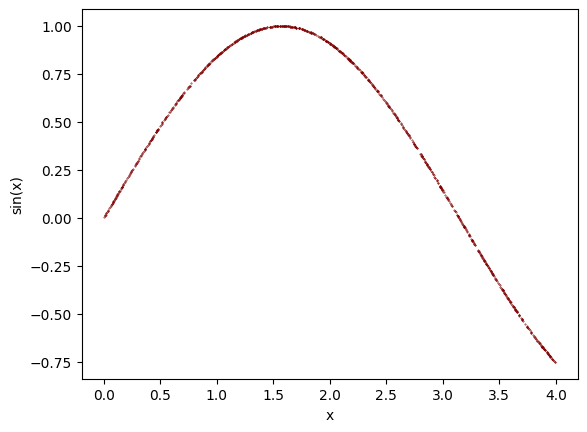

In [33]:
plt.scatter(df['x'], df['y'], color = 'maroon', marker = '.', s = 0.5)
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.show()

### Data set split

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df['x'], df['y'], train_size = 0.8, shuffle = True)

### Creating a network model

In [9]:
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

In [24]:
model = Sequential()
model.add(Dense(4, input_dim = 1, activation = 'tanh'))
model.add(Dense(5, activation = 'tanh'))
model.add(Dense(1, activation = 'linear'))

In [25]:
model.compile(loss = 'mse', optimizer = 'adam')

In [26]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 4)                 8         
                                                                 
 dense_4 (Dense)             (None, 5)                 25        
                                                                 
 dense_5 (Dense)             (None, 1)                 6         
                                                                 
Total params: 39 (156.00 Byte)
Trainable params: 39 (156.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [27]:
early_stop = EarlyStopping(monitor = 'loss', patience = 2, verbose = 1)

### Fit the model

In [28]:
history = model.fit(X_train, y_train, epochs = 10, batch_size = 1, callbacks = [early_stop])

Epoch 1/10
800/800 [==============================] - 4s 3ms/step - loss: 0.1420
Epoch 2/10
800/800 [==============================] - 3s 4ms/step - loss: 0.0622
Epoch 3/10
800/800 [==============================] - 3s 4ms/step - loss: 0.0263
Epoch 4/10
800/800 [==============================] - 3s 3ms/step - loss: 0.0111
Epoch 5/10
800/800 [==============================] - 2s 3ms/step - loss: 0.0043
Epoch 6/10
800/800 [==============================] - 3s 4ms/step - loss: 0.0020
Epoch 7/10
800/800 [==============================] - 3s 4ms/step - loss: 0.0012
Epoch 8/10
800/800 [==============================] - 3s 3ms/step - loss: 9.2018e-04
Epoch 9/10
800/800 [==============================] - 4s 5ms/step - loss: 6.9419e-04
Epoch 10/10
800/800 [==============================] - 3s 4ms/step - loss: 5.0636e-04


### History

In [30]:
print(history.history)

{'loss': [0.14195984601974487, 0.06222553178668022, 0.026285946369171143, 0.011058722622692585, 0.004281975328922272, 0.002009646501392126, 0.0012314959894865751, 0.0009201836655847728, 0.000694189453497529, 0.0005063642747700214]}


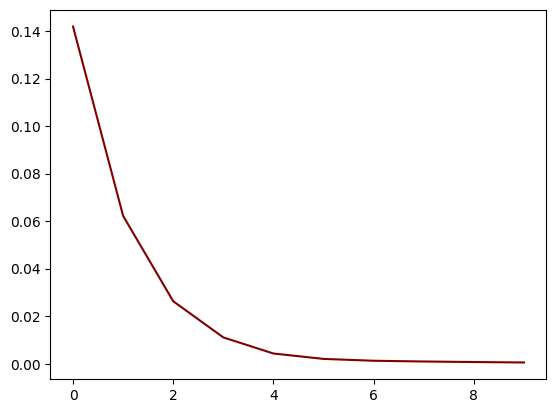

In [34]:
plt.plot(history.history['loss'], color = 'maroon', label = 'Historical loss in training')
plt.show()

### Accuracy

In [35]:
train_accuracy = model.evaluate(X_train, y_train)
test_accuracy = model.evaluate(X_test, y_test)

7/7 [==============================] - 0s 3ms/step - loss: 2.9406e-04


### Make predictions

In [22]:
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

25/25 [==============================] - 0s 3ms/step


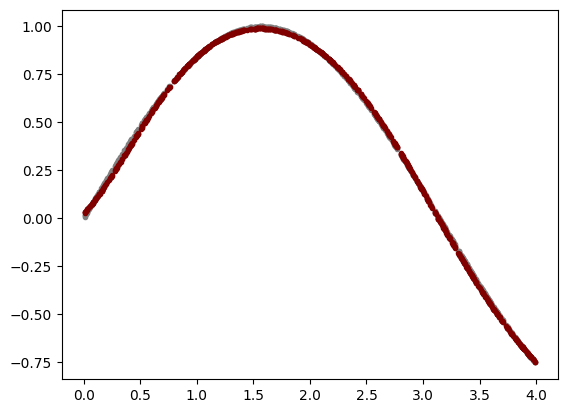

In [23]:
plt.scatter(X_train, y_train, marker = '.', color = 'grey')
plt.scatter(X_train, y_pred_train, marker = '.', color = 'maroon')
plt.show()

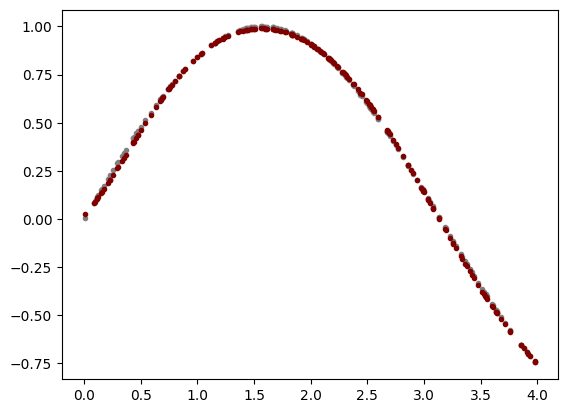

In [20]:
plt.scatter(X_test, y_test, marker = '.', color = 'grey')
plt.scatter(X_test, y_pred, marker = '.', color = 'maroon')
plt.show()